<a href="https://colab.research.google.com/github/tabasumnaziyashaik/CodeAlpha_Iris_Classification/blob/main/Task4_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

In [ ]:
!rm 'archive (1).zip'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Advertising.csv to Advertising.csv


In [ ]:
import pandas as pd
df = pd.read_csv('Advertising.csv')
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('Advertising.csv')


df = df.drop('Unnamed: 0', axis=1)

print("Shape:", df.shape)
print("\nData Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (200, 4)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Missing Values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


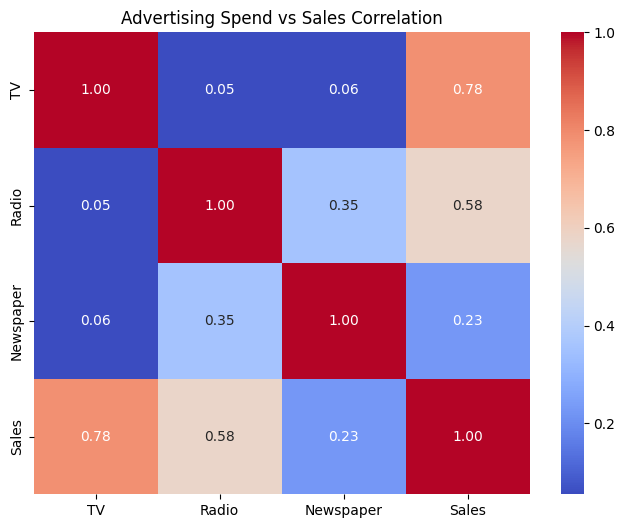

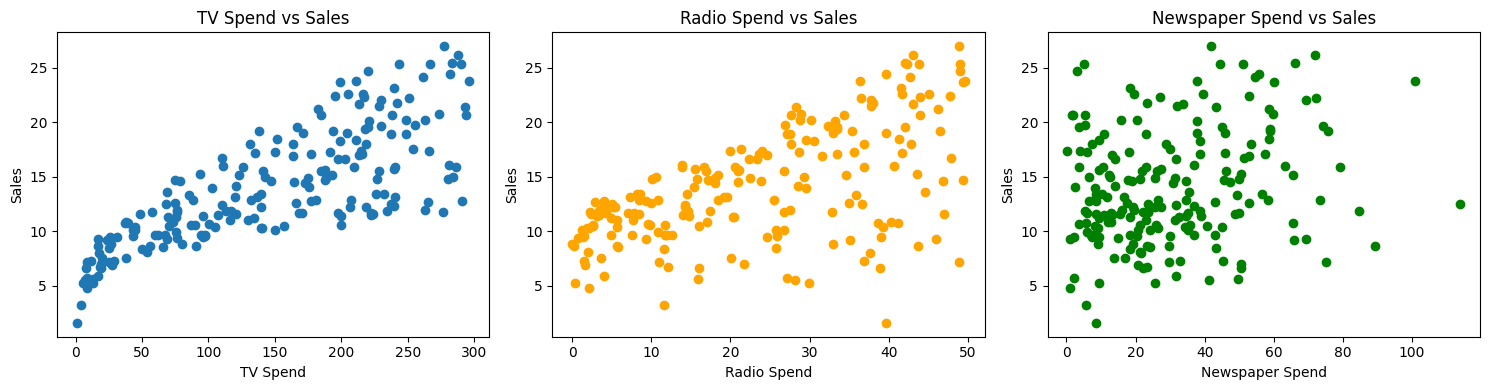

In [ ]:

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Advertising Spend vs Sales Correlation')
plt.show()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV Spend')
plt.ylabel('Sales')
plt.title('TV Spend vs Sales')

plt.subplot(1,3,2)
plt.scatter(df['Radio'], df['Sales'], color='orange')
plt.xlabel('Radio Spend')
plt.ylabel('Sales')
plt.title('Radio Spend vs Sales')

plt.subplot(1,3,3)
plt.scatter(df['Newspaper'], df['Sales'], color='green')
plt.xlabel('Newspaper Spend')
plt.ylabel('Sales')
plt.title('Newspaper Spend vs Sales')

plt.tight_layout()
plt.show()

In [ ]:

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Model Performance:")
print("R2 Score:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))


coefficients = pd.DataFrame({'Feature': X.columns, 'Impact on Sales': model.coef_})
coefficients = coefficients.sort_values('Impact on Sales', ascending=False)
print("\nActionable Insights - Kisme paisa lagaye:")
print(coefficients)
print(f"\nIntercept: {model.intercept_:.2f}")

Model Performance:
R2 Score: 0.899
MAE: 1.461
RMSE: 1.782

Actionable Insights - Kisme paisa lagaye:
     Feature  Impact on Sales
1      Radio         0.189195
0         TV         0.044730
2  Newspaper         0.002761

Intercept: 2.98


In [ ]:

new_budget = pd.DataFrame({
    'TV': [200],
    'Radio': [40],
    'Newspaper': [60]
})

predicted_sales = model.predict(new_budget)
print(f"TV=200, Radio=40, Newspaper=60 spend karne pe Sales hogi: {predicted_sales[0]:.2f} units")

TV=200, Radio=40, Newspaper=60 spend karne pe Sales hogi: 19.66 units


In [ ]:
print("Model Performance:")
print("R2 Score:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("\nFull Feature Impact:")
coefficients = pd.DataFrame({'Feature': X.columns, 'Impact on Sales': model.coef_})
print(coefficients.sort_values('Impact on Sales', ascending=False))

Model Performance:
R2 Score: 0.899
MAE: 1.461

Full Feature Impact:
     Feature  Impact on Sales
1      Radio         0.189195
0         TV         0.044730
2  Newspaper         0.002761
